In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl
from scipy.stats import mannwhitneyu

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/nearest_neighbour.csv')
df1['Condition'] = 'Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/nearest_neighbour.csv')
df2['Condition'] = 'Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/nearest_neighbour.csv')
df3['Condition'] = 'Starved-Starved'

df = pd.concat([df1, df2, df3], ignore_index=True)


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_64220/394834709.py:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(rect=[1, 1, 1, 1])


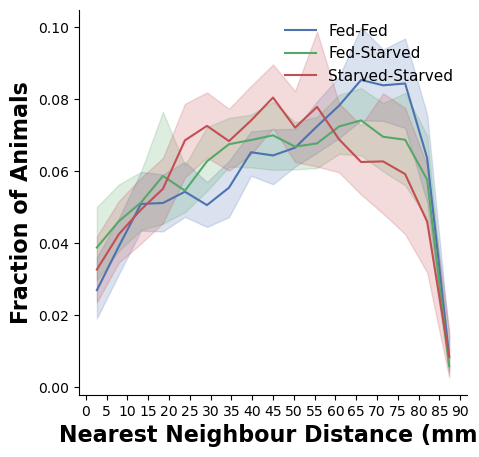

In [2]:

bins = np.linspace(0, 90, 18)  # 0 to 90 in 5 increments
df['bin'] = pd.cut(df['head_distance'], bins, include_lowest=True)
df['bin_center'] = df['bin'].apply(lambda x: x.mid)


# Count per file-condition-bin
counts = (
    df.groupby(['filename', 'Condition', 'bin_center'])
    .size()
    .groupby(['filename', 'Condition'], group_keys=False)
    .apply(lambda x: x / x.sum())
    .reset_index(name='density')
)

palette = {
    'Fed-Fed': '#4C72B0',
    'Fed-Starved': '#55A868',
    'Starved-Starved': '#C44E52',
}

plt.figure(figsize=(5,5))

ax = sns.lineplot(data=counts, x='bin_center', y='density', hue='Condition', errorbar=('ci', 95), palette=palette) 
plt.xlabel('Nearest Neighbour Distance (mm)', fontsize=16, fontweight='bold')
plt.ylabel('Fraction of Animals', fontsize=16, fontweight='bold')
sns.despine()
ax.legend(frameon=False, title=None, fontsize=11, loc="upper right")

# plt.title('Nearest Neighour Distance Distriubtion', fontsize=16, fontweight='bold')

plt.tight_layout(rect=[1, 1, 1, 1])

# plt.ylim(0, 0.03)

ax.set_xticks(np.arange(0, 91, 5))

plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/nearest-neighbour-distance.pdf', format='pdf')
# Show the plot
plt.show()



/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_64220/1079795551.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


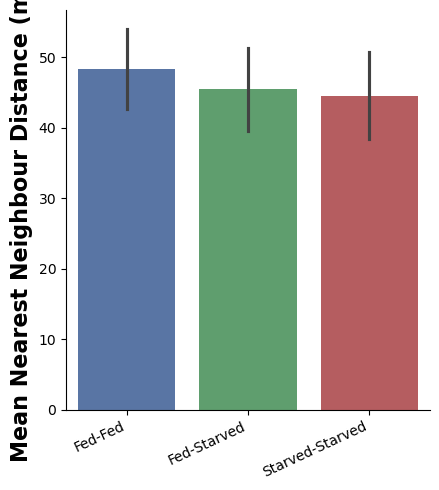

,condition_a,condition_b,n_a,n_b,U_statistic,p_value
0,Fed-Fed,Fed-Starved,26,28,455.0,0.117179
1,Fed-Fed,Starved-Starved,26,20,364.0,0.021825
2,Fed-Starved,Starved-Starved,28,20,330.0,0.300598


In [4]:
# Average nearest-neighbour distance per file and condition
avg_nn_by_file = (
    df.groupby(['Condition', 'filename'], as_index=False)['head_distance']
    .mean()
    .rename(columns={'head_distance': 'mean_nearest_neighbour_distance'})
)

condition_order = ['Fed-Fed', 'Fed-Starved', 'Starved-Starved']

plt.figure(figsize=(4.5, 5))
ax = sns.barplot(
    data=avg_nn_by_file,
    x='Condition',
    y='mean_nearest_neighbour_distance',
    order=condition_order,
    palette=palette,
    errorbar='sd',
)


plt.xlabel('')
plt.ylabel('Mean Nearest Neighbour Distance (mm)', fontsize=16, fontweight='bold')
plt.xticks(rotation=25, ha='right')
sns.despine()
plt.tight_layout()

plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/average-nearest-neighbour-distance-barplot.pdf', format='pdf')
plt.show()

mann_whitney_results = []
for i, condition_a in enumerate(condition_order):
    for condition_b in condition_order[i + 1:]:
        values_a = avg_nn_by_file.loc[
            avg_nn_by_file['Condition'] == condition_a,
            'mean_nearest_neighbour_distance',
        ]
        values_b = avg_nn_by_file.loc[
            avg_nn_by_file['Condition'] == condition_b,
            'mean_nearest_neighbour_distance',
        ]
        statistic, p_value = mannwhitneyu(values_a, values_b, alternative='two-sided')
        mann_whitney_results.append({
            'condition_a': condition_a,
            'condition_b': condition_b,
            'n_a': len(values_a),
            'n_b': len(values_b),
            'U_statistic': statistic,
            'p_value': p_value,
        })

mann_whitney_results = pd.DataFrame(mann_whitney_results)
mann_whitney_results
